# Telco Customer Churn Data Preparation

## Objective

Prepare raw customer data for churn analysis by performing data quality checks, correcting inconsistencies, validating data types, and creating an analysis-ready dataset for SQL analysis, statistical testing, and Power BI reporting.

In [83]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pylab as plt

Loading the data

### Dataset Overview

The dataset contains customer-level information including:

- Demographics
- Account information
- Services subscribed
- Billing information
- Churn status

The target variable is customer churn.

In [84]:
telco_churn = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
telco_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [85]:
telco_churn.shape

(7043, 21)

In [86]:
telco_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [87]:
telco_churn.columns = (telco_churn.columns.str.strip().str.lower().str.replace(" ", "_"))
telco_churn.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

Finding missing values

In [88]:
missing_summary = pd.DataFrame({
    "missing_count": telco_churn.isna().sum(),
    "missing_percentage": 
        (telco_churn.isna().mean()*100).round(2)
})

missing_summary.sort_values(
    "missing_percentage",
    ascending=False
)

,missing_count,missing_percentage
customerid,0,0.0
gender,0,0.0
seniorcitizen,0,0.0
partner,0,0.0
dependents,0,0.0
tenure,0,0.0
phoneservice,0,0.0
multiplelines,0,0.0
internetservice,0,0.0
onlinesecurity,0,0.0


## Duplicate Analysis

In [89]:
telco_churn.duplicated().sum()

np.int64(0)

Duplicate customer records were evaluated using customer identifiers. No duplicate records were identified.

Fixing data type

In [90]:
telco_churn.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges         object
churn                object
dtype: object

In [91]:
telco_churn['totalcharges'] = pd.to_numeric(telco_churn['totalcharges'], errors='coerce')

In [92]:
telco_churn.loc[telco_churn['totalcharges'].isna(), ['tenure', 'monthlycharges', 'totalcharges']]

,tenure,monthlycharges,totalcharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


Total charges contained blank values that represented customers with zero tenure. These values were converted and validated against tenure and monthly charges before replacement.

In [93]:
telco_churn.loc[telco_churn['tenure'] == 0, 'totalcharges'] = 0

In [94]:
orig = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv", usecols=["customerID", "Churn"])

orig = orig.rename(columns={"customerID": "customerid", "Churn": "churn"})

telco_churn = (telco_churn.drop(columns=["churn"], errors="ignore").merge(orig, on="customerid", how="left"))

telco_churn["churn"] = telco_churn["churn"].astype(str).str.strip().map({"Yes": 1, "No": 0})

print("Missing churn:", telco_churn["churn"].isna().sum())
print(telco_churn["churn"].value_counts(dropna=False))
telco_churn.head()


Missing churn: 0
churn
0    5174
1    1869
Name: count, dtype: int64


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [95]:
telco_churn["churn"].value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

In [96]:
telco_churn.isna().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

## Tenure groups

In [97]:
telco_churn["tenure_group"] = pd.cut(
    telco_churn["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ],
    include_lowest=True
)

In [98]:
telco_churn[["tenure", "tenure_group"]].head(10)

,tenure,tenure_group
0,1,0-12 months
1,34,25-48 months
2,2,0-12 months
3,45,25-48 months
4,2,0-12 months
5,8,0-12 months
6,22,13-24 months
7,10,0-12 months
8,28,25-48 months
9,62,49-72 months


In [99]:
telco_churn["tenure_group"].value_counts().sort_index()

tenure_group
0-12 months     2186
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64

In [100]:
print(telco_churn["tenure_group"].isna().sum())

0


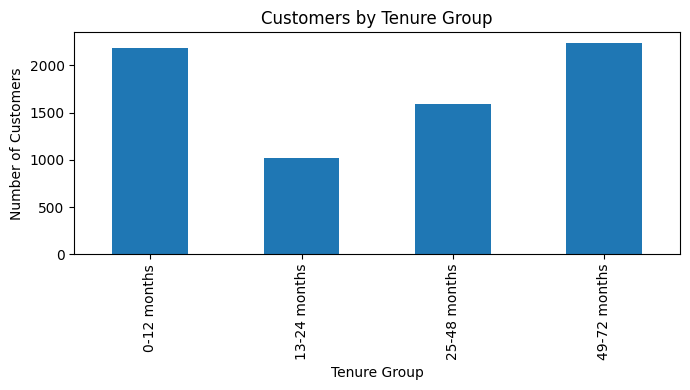

In [101]:
telco_churn["tenure_group"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Customers by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Normalize Service Columns

In [102]:
service_cols = [
    "onlinesecurity",
    "onlinebackup",
    "deviceprotection",
    "techsupport",
    "streamingtv",
    "streamingmovies"
]
telco_churn[service_cols] = telco_churn[service_cols].replace("No internet service", "No")

In [103]:
for col in service_cols:
    telco_churn[col] = telco_churn[col].astype(str).str.strip().map({"Yes": 1, "No": 0})

In [104]:
"customerid" in telco_churn.columns

True

# Remove unique customer identifier because it has no analytical value
# and should not be used in churn analysis.

In [105]:
telco_churn = telco_churn.drop(
    columns=["customerid"],
    errors="ignore"
)

In [106]:
telco_churn[service_cols].isna().sum()
telco_churn.dtypes

gender                object
seniorcitizen          int64
partner               object
dependents            object
tenure                 int64
phoneservice          object
multiplelines         object
internetservice       object
onlinesecurity         int64
onlinebackup           int64
deviceprotection       int64
techsupport            int64
streamingtv            int64
streamingmovies        int64
contract              object
paperlessbilling      object
paymentmethod         object
monthlycharges       float64
totalcharges         float64
churn                  int64
tenure_group        category
dtype: object

# Final data quality validation

In [107]:
print(f"Final rows: {telco_churn.shape[0]:,}")
print(f"Final columns: {telco_churn.shape[1]}")
print(f"Duplicate rows: {telco_churn.duplicated().sum()}")
print(f"Total missing values: {telco_churn.isna().sum().sum()}")

print("\nMissing values by column:")
print(telco_churn.isna().sum()[telco_churn.isna().sum() > 0])

print("\nData types:")
print(telco_churn.dtypes)

print("\nChurn distribution:")
print(telco_churn["churn"].value_counts(dropna=False))

print("\nTenure group distribution:")
print(telco_churn["tenure_group"].value_counts(dropna=False).sort_index())

Final rows: 7,043
Final columns: 21
Duplicate rows: 22
Total missing values: 0

Missing values by column:
Series([], dtype: int64)

Data types:
gender                object
seniorcitizen          int64
partner               object
dependents            object
tenure                 int64
phoneservice          object
multiplelines         object
internetservice       object
onlinesecurity         int64
onlinebackup           int64
deviceprotection       int64
techsupport            int64
streamingtv            int64
streamingmovies        int64
contract              object
paperlessbilling      object
paymentmethod         object
monthlycharges       float64
totalcharges         float64
churn                  int64
tenure_group        category
dtype: object

Churn distribution:
churn
0    5174
1    1869
Name: count, dtype: int64

Tenure group distribution:
tenure_group
0-12 months     2186
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64


In [108]:
telco_churn[telco_churn.duplicated()]

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_group
964,Male,0,No,No,1,Yes,No,DSL,0,0,...,0,0,0,Month-to-month,Yes,Mailed check,45.70,45.70,1,0-12 months
1338,Male,0,No,No,1,Yes,No,No,0,0,...,0,0,0,Month-to-month,No,Mailed check,20.15,20.15,1,0-12 months
1491,Female,0,No,No,1,Yes,No,No,0,0,...,0,0,0,Month-to-month,No,Mailed check,19.55,19.55,0,0-12 months
1739,Male,0,No,No,1,Yes,No,Fiber optic,0,0,...,0,0,0,Month-to-month,Yes,Electronic check,69.90,69.90,1,0-12 months
1932,Male,0,No,No,1,Yes,No,No,0,0,...,0,0,0,Month-to-month,No,Mailed check,20.20,20.20,0,0-12 months
2713,Male,0,No,No,1,Yes,No,No,0,0,...,0,0,0,Month-to-month,Yes,Mailed check,20.45,20.45,0,0-12 months
2892,Male,0,No,No,1,Yes,No,No,0,0,...,0,0,0,Month-to-month,No,Mailed check,20.45,20.45,0,0-12 months
3301,Female,1,No,No,1,Yes,No,Fiber optic,0,0,...,0,0,0,Month-to-month,Yes,Electronic check,69.60,69.60,1,0-12 months
3754,Male,0,No,No,1,Yes,No,No,0,0,...,0,0,0,Month-to-month,No,Mailed check,20.05,20.05,0,0-12 months
4098,Male,0,No,No,1,Yes,No,No,0,0,...,0,0,0,Month-to-month,Yes,Mailed check,20.20,20.20,1,0-12 months


# Check duplicates in the raw dataset

In [109]:
raw_df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [110]:

raw_df.duplicated().sum()

np.int64(0)

In [111]:
print("Duplicate customer IDs:", raw_df["customerID"].duplicated().sum())

Duplicate customer IDs: 0


After removing `customerID`, 22 observations shared identical analytical features. These were not treated as duplicate records because the original dataset confirmed each customer identifier was unique. The matching feature combinations represent different customers with identical attributes rather than data quality issues.

Saving the clean data in processed file

In [114]:
telco_churn.to_csv('../data/processed/telco_churn_clean.csv', index=False)